# Masterclass de Clustering (con Temporalidad) — Online Retail II
**Autor:** Josef Rodriguez  
**Dataset (repo):** `data/online_retail_II.xlsx` (2 sheets)  
**RAW URL (fallback):** `https://raw.githubusercontent.com/josefrodrim/ML-course/main/data/online_retail_II.xlsx`

Este notebook esta pensado para correr **desde tu repo**. Si el Excel no existe localmente, lo descarga desde GitHub RAW.

## Flujo de la masterclass
1) Diccionario de datos (formal)  
2) Limpieza y reglas de calidad  
3) Feature engineering **cliente–mes** con **ventana movil**  
4) Modelos: K-Means, Jerarquico (Ward), DBSCAN  
5) Seleccion de hiperparametros (K, eps)  
6) Evaluacion (Silhouette, Davies-Bouldin, Calinski-Harabasz)  
7) Visualizacion (PCA 2D)  
8) Estabilidad temporal y migracion de clusters  
9) Persistencia para produccion (scaler + modelo + features)

In [1]:
# ===============================
# 0) Imports y configuracion
# ===============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from datetime import datetime

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.neighbors import NearestNeighbors

import joblib
import urllib.request

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)

print("OK - imports")

OK - imports


## 1) Diccionario de Datos (resumen formal)
**Variables raw:**
- InvoiceNo (string): factura; inicia con 'C' = cancelacion
- StockCode (string): codigo producto
- Description (string): descripcion
- Quantity (int): cantidad; negativos = devoluciones
- UnitPrice (float): precio unitario; filtrar <= 0
- InvoiceDate (datetime): timestamp (clave)
- CustomerID (string): id cliente; puede ser nulo
- Country (string): pais

**Features para clustering (por cliente y tiempo):**
- Monetary: \(\sum Quantity \cdot UnitPrice\)
- Frequency: #InvoiceNo distintos en ventana
- Recency: dias desde ultima compra al cierre del mes
- Ticket promedio: Monetary / Frequency
- Diversidad: #StockCode distintos

## 2) Carga desde tu repo (Excel con 2 sheets)
Este dataset tiene 2 hojas:
- `Year 2009-2010`
- `Year 2010-2011`

El loader:
1) Lee el Excel local `data/online_retail_II.xlsx`
2) Si no existe, lo descarga desde RAW de GitHub
3) Concatena ambas hojas y estandariza tipos

In [2]:
# ===============================
# 2) Loader robusto (local -> descarga -> leer 2 sheets)
# ===============================
DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

xlsx_path = DATA_DIR / "online_retail_II.xlsx"
csv_path  = DATA_DIR / "online_retail_II_full.csv"

RAW_URL = "https://raw.githubusercontent.com/josefrodrim/ML-course/main/data/online_retail_II.xlsx"

def ensure_xlsx_local(xlsx_path: Path, raw_url: str) -> Path:
    if xlsx_path.exists() and xlsx_path.stat().st_size > 0:
        return xlsx_path
    print("No se encontro Excel local. Descargando desde GitHub RAW...")
    urllib.request.urlretrieve(raw_url, xlsx_path.as_posix())
    print("Descarga OK:", xlsx_path, "| size:", xlsx_path.stat().st_size/1024/1024, "MB")
    return xlsx_path

def load_online_retail_from_xlsx(xlsx_path: Path) -> pd.DataFrame:
    # engine openpyxl suele ser necesario
    df_2009 = pd.read_excel(xlsx_path, sheet_name="Year 2009-2010", engine="openpyxl")
    df_2010 = pd.read_excel(xlsx_path, sheet_name="Year 2010-2011", engine="openpyxl")
    df = pd.concat([df_2009, df_2010], ignore_index=True)
    return df

def load_online_retail(csv_path: Path, xlsx_path: Path, raw_url: str) -> pd.DataFrame:
    if csv_path.exists():
        print("Cargando CSV:", csv_path)
        return pd.read_csv(csv_path)
    xlsx_path = ensure_xlsx_local(xlsx_path, raw_url)
    print("Cargando XLSX:", xlsx_path)
    return load_online_retail_from_xlsx(xlsx_path)

df_raw = load_online_retail(csv_path, xlsx_path, RAW_URL)
print("Shape raw:", df_raw.shape)
df_raw.head()

Cargando XLSX: data/online_retail_II.xlsx
Shape raw: (1067371, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [3]:
df_raw.shape

(1067371, 8)

In [4]:
df_raw.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country'], dtype='str')

In [5]:
# ==========================================
# Normalizacion de nombres de columnas
# ==========================================

print("Columnas originales:")
print(df_raw.columns)

# 1) Quitar espacios al inicio y final
df_raw.columns = df_raw.columns.str.strip()

# 2) Reemplazar espacios internos (ej: 'Customer ID' -> 'CustomerID')
df_raw.columns = df_raw.columns.str.replace(" ", "", regex=False)

# 3) (Opcional) Renombrado explicito por claridad
df_raw = df_raw.rename(columns={
    "CustomerID": "CustomerID"  # ya sin espacio, por seguridad
})

print("\nColumnas despues de normalizacion:")
print(df_raw.columns)

Columnas originales:
Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country'], dtype='str')

Columnas despues de normalizacion:
Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'CustomerID', 'Country'], dtype='str')


In [6]:
# ===============================
# 2.1) Estandarizar tipos
# ===============================
df = df_raw.copy()

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], errors="coerce")

# CustomerID puede venir float en Excel -> string
df["CustomerID"] = df["CustomerID"].astype("string")

df["Quantity"] = pd.to_numeric(df["Quantity"], errors="coerce")
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[us]
 5   Price        1067371 non-null  float64       
 6   CustomerID   824364 non-null   string        
 7   Country      1067371 non-null  str           
dtypes: datetime64[us](1), float64(1), int64(1), object(3), str(1), string(1)
memory usage: 65.1+ MB


## 3) Limpieza (reglas de calidad)
Reglas aplicadas (modo didactico):
1) Eliminar `CustomerID` nulo
2) Eliminar `InvoiceDate` nulo
3) Filtrar `Price > 0`
4) Filtrar `Quantity > 0` (solo compras; devoluciones se excluyen en esta clase)
5) Crear `LineAmount = Quantity * UnitPrice`

In [7]:
before = len(df)

df = df.dropna(subset=["CustomerID","InvoiceDate"])
df = df[df["Price"] > 0]
df = df[df["Quantity"] > 0]

df["LineAmount"] = df["Quantity"] * df["Price"]

after = len(df)
print(f"Filas antes: {before:,} | despues: {after:,} | removidas: {before-after:,} ({(before-after)/max(before,1):.2%})")
df.head()

Filas antes: 1,067,371 | despues: 805,549 | removidas: 261,822 (24.53%)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country,LineAmount
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


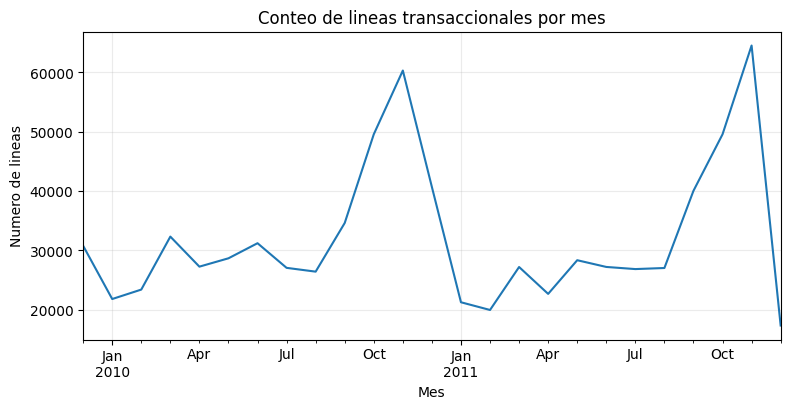

In [8]:
# Distribucion temporal (conteo de lineas por mes)
plt.figure(figsize=(9,4))
df["InvoiceDate"].dt.to_period("M").value_counts().sort_index().plot(kind="line")
plt.title("Conteo de lineas transaccionales por mes")
plt.xlabel("Mes")
plt.ylabel("Numero de lineas")
plt.grid(True, alpha=0.25)
plt.show()

## 4) Feature Engineering Temporal: Cliente–Mes con Ventana Movil


Sea:

$$
t
$$
Mes de referencia.

$$
t_{\text{end}}
$$
Ultimo dia del mes \( t \).

$$
W
$$
Ventana temporal (por ejemplo, \( W = 90 \) dias).

Definimos el intervalo de observacion:

$$
\mathcal{T}_{t,W}
=
\left(
t_{\text{end}} - W,\; t_{\text{end}}
\right]
$$ el intervalo de observacion  

La unidad de analisis es **Cliente–Mes**.

---

###  Monetary (Valor Monetario)

$$
M_{i,t,W}
=
\sum_{j \in \mathcal{T}_{t,W}}
\left(
Quantity_{i,j} \cdot Price_{i,j}
\right)
$$

Representa el gasto total del cliente \( i \) en la ventana \( W \).

---

###  Frequency (Frecuencia de Compra)

$$
F_{i,t,W}
=
\left|
\left\{
InvoiceNo_{i,j}
\; : \;
j \in \mathcal{T}_{t,W}
\right\}
\right|
$$

Es el numero de facturas distintas del cliente \( i \) en la ventana.

---

###  Recency (Recencia)

$$
R_{i,t}
=
\left(
t_{\text{end}}
-
\max_{j \in \mathcal{T}_{t,W}}
\left( InvoiceDate_{i,j} \right)
\right)_{\text{dias}}
$$

Mide los dias transcurridos desde la ultima compra hasta el cierre del mes \( t \).

---

###  Ticket Promedio

$$
Ticket_{i,t,W}
=
\frac{M_{i,t,W}}
{\max\left(F_{i,t,W},\,1\right)}
$$

Se utiliza el maximo con 1 para evitar division por cero.

---

###  Diversidad de Productos

$$
D_{i,t,W}
=
\left|
\left\{
StockCode_{i,j}
\; : \;
j \in \mathcal{T}_{t,W}
\right\}
\right|
$$

Numero de productos distintos adquiridos en la ventana.

---

###  Interpretacion Conceptual

- \( M \) captura el **valor economico**
- \( F \) captura la **intensidad de compra**
- \( R \) captura la **actividad reciente**
- \( Ticket \) captura el **nivel promedio de gasto**
- \( D \) captura la **variedad de consumo**

In [9]:
WINDOW_DAYS = 90

df["month"] = df["InvoiceDate"].dt.to_period("M").dt.to_timestamp()
months = pd.Series(df["month"].unique()).sort_values().to_list()
print("Meses:", len(months), "|", min(months), "->", max(months))

def build_customer_month_features(df_in: pd.DataFrame, months, window_days: int) -> pd.DataFrame:
    out = []
    for m in months:
        month_start = pd.Timestamp(m)
        month_end = month_start + pd.offsets.MonthEnd(0)
        window_start = month_end - pd.Timedelta(days=window_days)

        w = df_in[(df_in["InvoiceDate"] > window_start) & (df_in["InvoiceDate"] <= month_end)].copy()
        if w.empty:
            continue

        g = w.groupby("CustomerID").agg(
            monetary=("LineAmount","sum"),
            freq_invoices=("Invoice", pd.Series.nunique),
            qty_total=("Quantity","sum"),
            unique_products=("StockCode", pd.Series.nunique),
            last_purchase=("InvoiceDate","max"),
            country=("Country", lambda x: x.mode().iloc[0] if len(x.mode()) else x.iloc[0]),
        ).reset_index()

        g["month"] = month_start
        g["recency_days"] = (month_end - g["last_purchase"]).dt.days.clip(lower=0)
        g["ticket_avg"] = g["monetary"] / np.maximum(g["freq_invoices"], 1)

        out.append(g.drop(columns=["last_purchase"]))

    return pd.concat(out, ignore_index=True)

cm = build_customer_month_features(df, months, WINDOW_DAYS)
print("Cliente-mes:", cm.shape)
cm.head()

Meses: 25 | 2009-12-01 00:00:00 -> 2011-12-01 00:00:00
Cliente-mes: (51117, 9)


,CustomerID,monetary,freq_invoices,qty_total,unique_products,country,month,recency_days,ticket_avg
0,12346.0,113.50,5,26,2,United Kingdom,2009-12-01,12,22.700
1,12358.0,1429.83,1,309,17,Austria,2009-12-01,22,1429.830
2,12359.0,838.89,2,609,34,Cyprus,2009-12-01,14,419.445
3,12362.0,130.00,1,1,1,Belgium,2009-12-01,29,130.000
4,12417.0,317.60,2,152,19,Belgium,2009-12-01,20,158.800


In [10]:
# Chequeo rapido de features (raw)
feat_raw = ["monetary","freq_invoices","recency_days","ticket_avg","unique_products","qty_total"]
cm[feat_raw].describe().T

,count,mean,std,min,25%,50%,75%,max
monetary,51117.0,985.001294,3364.322760,0.85,239.620,430.28,871.60,168469.6
freq_invoices,51117.0,2.058200,2.630118,1.00,1.000,1.00,2.00,84.0
recency_days,51117.0,34.896414,25.083610,0.00,13.000,30.00,54.00,89.0
ticket_avg,51117.0,420.302141,1089.482399,0.85,183.955,306.33,463.12,168469.6
unique_products,51117.0,36.334233,45.723738,1.00,12.000,24.00,45.00,1164.0
qty_total,51117.0,596.446564,2619.848441,1.00,119.000,248.00,508.00,220506.0


## 5) Preparacion (log + escalamiento)
En retail (y banca) hay colas pesadas. Usamos `log1p` para estabilizar, y luego escalamos:

$$
z = \frac{x - \mu}{\sigma}
$$

In [11]:
cm2 = cm.copy()

for c in ["monetary","ticket_avg","qty_total","unique_products","freq_invoices"]:
    cm2[f"log_{c}"] = np.log1p(cm2[c])

feat_model = ["log_monetary","log_ticket_avg","log_qty_total","log_unique_products","log_freq_invoices","recency_days"]

X = cm2[feat_model].replace([np.inf, -np.inf], np.nan).dropna()
cm2 = cm2.loc[X.index].reset_index(drop=True)
X = X.reset_index(drop=True)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("X:", X.shape, "| X_scaled:", X_scaled.shape)

X: (51117, 6) | X_scaled: (51117, 6)


## 6) Segmentacion ABC (A=alto valor, B=valor medio, C=bajo valor) usando Ranking RFM

En vez de usar el ID de un cluster, vamos a crear **segmentos accionables** a partir de un **ranking RFM**:

- **R (Recency):** dias desde la ultima compra (menor = mejor)
- **F (Frequency):** numero de facturas (mayor = mejor)
- **M (Monetary):** gasto total (mayor = mejor)

Luego construimos un **score de valor** y asignamos:

- **A:** mejores clientes (top del score)
- **B:** valor medio
- **C:** bajo valor

> Nota: Para mantener comparabilidad en el tiempo, el ranking se calcula **dentro de cada mes** (cliente–mes).


In [12]:
# ===============================
# 6.1) Parametros ABC por RFM
# ===============================
# Cortes tipicos (pareto): A=20%, B=30%, C=50%
A_SHARE = 0.20
B_SHARE = 0.30  # el resto es C

# Pesos del score (puedes ajustarlos; deben sumar 1.0)
W_M = 0.40
W_F = 0.30
W_R = 0.30

assert 0 < A_SHARE < 1 and 0 < B_SHARE < 1 and A_SHARE + B_SHARE < 1
assert abs((W_M + W_F + W_R) - 1.0) < 1e-9

# ===============================
# 6.2) Ranking RFM por mes
# ===============================
# Trabajamos sobre cm2 (cliente-mes), que ya tiene: monetary, freq_invoices, recency_days
rfm = cm2.copy()

# Rank percentil dentro de cada mes:
# - monetary: mayor es mejor
# - freq_invoices: mayor es mejor
# - recency_days: menor es mejor -> rank sobre -recency_days
rfm["M_rank"] = rfm.groupby("month")["monetary"].rank(method="average", pct=True, ascending=True)
rfm["F_rank"] = rfm.groupby("month")["freq_invoices"].rank(method="average", pct=True, ascending=True)
rfm["R_rank"] = rfm.groupby("month")["recency_days"].rank(method="average", pct=True, ascending=False)

# Score total (0..1 aprox). Mientras mas alto, mas valor.
rfm["RFM_score"] = W_M*rfm["M_rank"] + W_F*rfm["F_rank"] + W_R*rfm["R_rank"]

# ===============================
# 6.3) Cortes ABC por score (por mes)
# ===============================
def abc_label(score: float, q_a: float, q_b: float) -> str:
    # q_a: umbral para entrar a A (alto)
    # q_b: umbral para entrar a B (medio). score < q_b => C
    if score >= q_a:
        return "A"
    elif score >= q_b:
        return "B"
    else:
        return "C"

# Umbrales por mes
qs = (
    rfm.groupby("month")["RFM_score"]
    .quantile([1-A_SHARE, 1-(A_SHARE+B_SHARE)])
    .unstack()
    .rename(columns={1-A_SHARE: "q_A", 1-(A_SHARE+B_SHARE): "q_B"})
)

rfm = rfm.merge(qs, left_on="month", right_index=True, how="left")
rfm["segment_abc"] = rfm.apply(lambda r: abc_label(r["RFM_score"], r["q_A"], r["q_B"]), axis=1)

# Resultado final: dejamos el dataset principal con el segmento ABC
cm2 = rfm.drop(columns=["q_A","q_B"]).copy()

cm2["segment_abc"].value_counts().sort_index()


segment_abc
A    10233
B    15333
C    25551
Name: count, dtype: int64

## 7) Validaciones rapidas (sanity checks)

Queremos verificar que:

1) A tiene mayor valor monetario promedio que B, y B mayor que C.  
2) Los segmentos tienen un reparto aproximado cercano a (A,B,C) = (20%,30%,50%) por mes (puede variar por empates).  


In [13]:
# 7.1) Orden esperado por valor
profile_cols = ["monetary","freq_invoices","recency_days","ticket_avg","unique_products","qty_total","RFM_score"]
prof_abc = (
    cm2.groupby("segment_abc")[profile_cols]
    .agg(count=("RFM_score","size"),
         monetary_mean=("monetary","mean"),
         freq_mean=("freq_invoices","mean"),
         recency_mean=("recency_days","mean"),
         score_mean=("RFM_score","mean"))
    .sort_index()
)
prof_abc


,count,monetary_mean,freq_mean,recency_mean,score_mean
segment_abc,,,,,
A,10233,3019.797749,4.854393,12.328936,0.839240
B,15333,792.411050,1.848171,27.035870,0.591863
C,25551,285.651527,1.064381,48.651599,0.309500


In [14]:
# 7.2) Shares promedio por mes (para ver que el corte se comporta como esperamos)
shares_abc = (
    cm2.groupby(["month","segment_abc"]).size().reset_index(name="count")
)
shares_abc["share"] = shares_abc.groupby("month")["count"].transform(lambda x: x/x.sum())
shares_abc.groupby("segment_abc")["share"].mean().sort_index()


segment_abc
A    0.200198
B    0.299962
C    0.499841
Name: share, dtype: float64

## 8) Visuales: Distribucion del score y perfil por segmento

- Histograma del score  
- Boxplot de Monetary/Frequency/Recency por ABC  


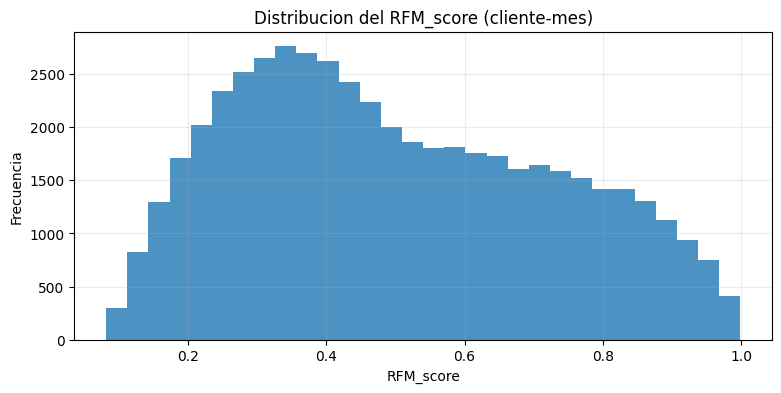

In [15]:
# Histograma del score
plt.figure(figsize=(9,4))
plt.hist(cm2["RFM_score"], bins=30, alpha=0.8)
plt.title("Distribucion del RFM_score (cliente-mes)")
plt.xlabel("RFM_score")
plt.ylabel("Frecuencia")
plt.grid(True, alpha=0.25)
plt.show()


/var/folders/mr/sqx7yj1d7qs1fr_mry8vz2x80000gn/T/ipykernel_26472/1682630855.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=["A","B","C"], showfliers=False)


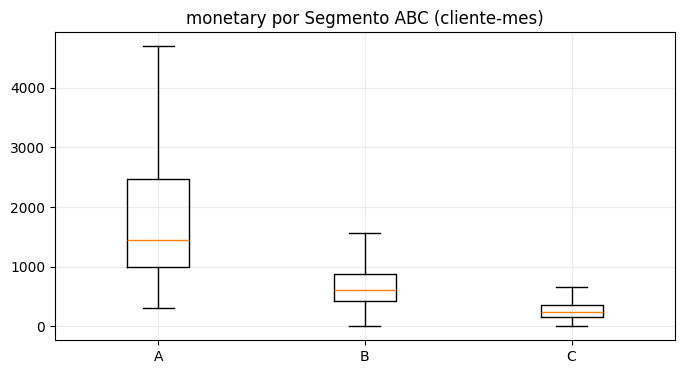

/var/folders/mr/sqx7yj1d7qs1fr_mry8vz2x80000gn/T/ipykernel_26472/1682630855.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=["A","B","C"], showfliers=False)


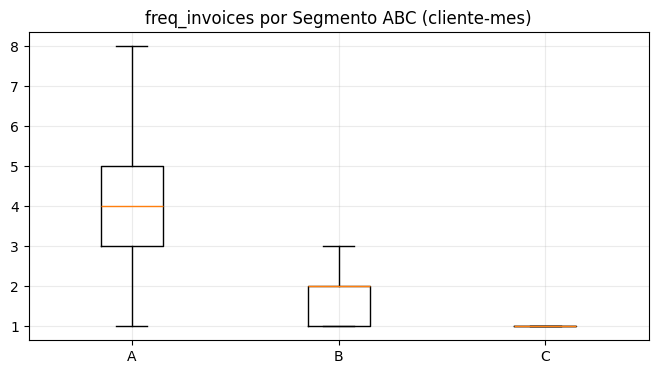

/var/folders/mr/sqx7yj1d7qs1fr_mry8vz2x80000gn/T/ipykernel_26472/1682630855.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=["A","B","C"], showfliers=False)


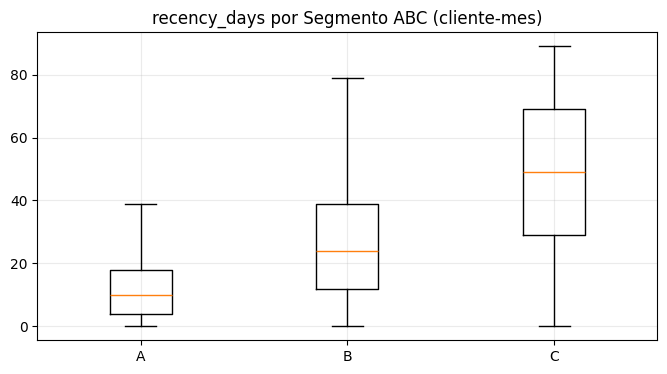

In [16]:
# Boxplots por segmento
for col in ["monetary","freq_invoices","recency_days"]:
    plt.figure(figsize=(8,4))
    data = [cm2.loc[cm2["segment_abc"]==s, col].values for s in ["A","B","C"]]
    plt.boxplot(data, labels=["A","B","C"], showfliers=False)
    plt.title(f"{col} por Segmento ABC (cliente-mes)")
    plt.grid(True, alpha=0.25)
    plt.show()


## 9) Perfilado accionable (tabla de negocio)

Esta tabla resume cada segmento en terminos operativos (promedios y medianas).  


In [17]:
# Perfilado completo (media + mediana)
prof = cm2.groupby("segment_abc")[["monetary","freq_invoices","recency_days","ticket_avg","unique_products","qty_total","RFM_score"]] \
          .agg(["count","mean","median"])

prof.columns = [f"{a}_{b}" for a,b in prof.columns]
prof = prof.reindex(["A","B","C"])
prof


,monetary_count,monetary_mean,monetary_median,freq_invoices_count,freq_invoices_mean,freq_invoices_median,recency_days_count,recency_days_mean,recency_days_median,ticket_avg_count,ticket_avg_mean,ticket_avg_median,unique_products_count,unique_products_mean,unique_products_median,qty_total_count,qty_total_mean,qty_total_median,RFM_score_count,RFM_score_mean,RFM_score_median
segment_abc,,,,,,,,,,,,,,,,,,,,,
A,10233,3019.797749,1449.14,10233,4.854393,4.0,10233,12.328936,10.0,10233,606.662173,407.73,10233,74.252223,55.0,10233,1801.179420,820.0,10233,0.839240,0.832988
B,15333,792.411050,610.60,15333,1.848171,2.0,15333,27.035870,24.0,15333,533.469110,350.85,15333,38.565512,31.0,15333,496.353095,336.0,15333,0.591863,0.590187
C,25551,285.651527,247.76,25551,1.064381,1.0,25551,48.651599,49.0,25551,277.755418,232.65,25551,19.809362,15.0,25551,174.024813,131.0,25551,0.309500,0.315959


## 10) Temporalidad: estabilidad y migracion de segmentos ABC

1) Shares por mes  
2) Matriz de transicion por cliente (t -> t+1)  


In [18]:
# 10.1) Shares por mes (ABC)
shares = (
    cm2
    .groupby(["month", "segment_abc"])
    .size()
    .reset_index(name="count")
)

shares["share"] = shares.groupby("month")["count"].transform(lambda x: x / x.sum())

pivot = (
    shares
    .pivot(index="month", columns="segment_abc", values="share")
    .fillna(0)
    .sort_index()
)

pivot.head()


segment_abc,A,B,C
month,,,
2009-12-01,0.200000,0.300524,0.499476
2010-01-01,0.200457,0.299543,0.500000
2010-02-01,0.200118,0.300177,0.499706
2010-03-01,0.200449,0.299832,0.499719
2010-04-01,0.200410,0.299846,0.499744


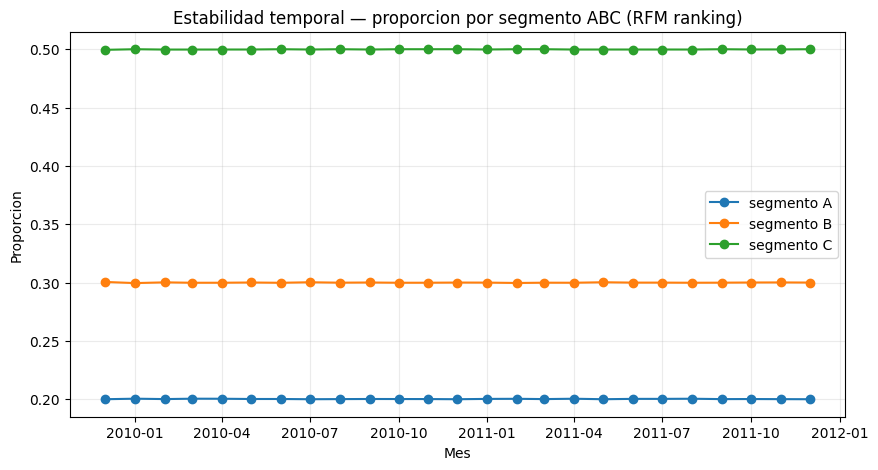

In [19]:
# 10.2) Curvas de estabilidad
plt.figure(figsize=(10,5))
for s in ["A","B","C"]:
    if s in pivot.columns:
        plt.plot(pivot.index, pivot[s], marker="o", label=f"segmento {s}")
plt.title("Estabilidad temporal — proporcion por segmento ABC (RFM ranking)")
plt.xlabel("Mes")
plt.ylabel("Proporcion")
plt.grid(True, alpha=0.25)
plt.legend()
plt.show()


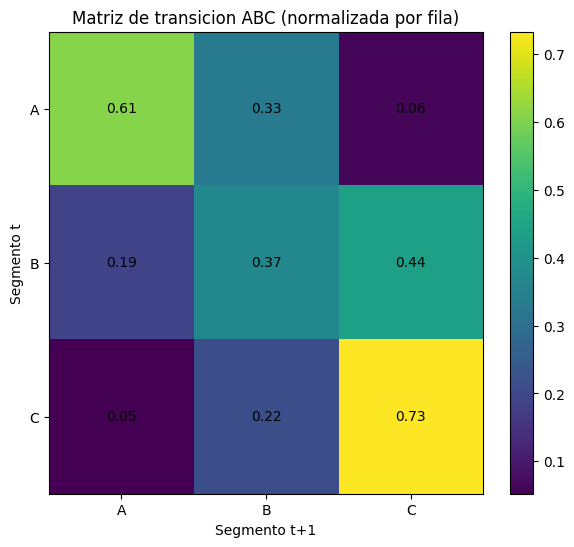

segment_next,A,B,C
segment_abc,,,
A,0.610122,0.329081,0.060796
B,0.190188,0.370424,0.439388
C,0.052393,0.215056,0.732552


In [20]:
# 10.3) Matriz de transicion (A/B/C) por cliente
cm_sorted = cm2.sort_values(["CustomerID","month"]).copy()
cm_sorted["segment_next"] = cm_sorted.groupby("CustomerID")["segment_abc"].shift(-1)

trans = cm_sorted.dropna(subset=["segment_next"]).copy()

mat = pd.crosstab(trans["segment_abc"], trans["segment_next"], normalize="index").reindex(index=["A","B","C"], columns=["A","B","C"]).fillna(0)

plt.figure(figsize=(7,6))
plt.imshow(mat.values, aspect="auto")
plt.title("Matriz de transicion ABC (normalizada por fila)")
plt.xlabel("Segmento t+1")
plt.ylabel("Segmento t")
plt.xticks(range(mat.shape[1]), mat.columns)
plt.yticks(range(mat.shape[0]), mat.index)
plt.colorbar()
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        plt.text(j, i, f"{mat.values[i,j]:.2f}", ha="center", va="center")
plt.show()

mat


## 11) Snapshot de segmentacion (ultimo mes disponible)

En muchos casos de negocio, el segmento se define en el **ultimo mes** (foto actual) para ejecutar campañas.  


In [21]:
# Ultimo mes disponible
last_month = cm2["month"].max()
snap = cm2[cm2["month"]==last_month].copy()

snap_counts = snap["segment_abc"].value_counts().reindex(["A","B","C"]).fillna(0).astype(int)
snap_revenue = snap.groupby("segment_abc")["monetary"].sum().reindex(["A","B","C"]).fillna(0)

snap_summary = pd.DataFrame({
    "clientes": snap_counts,
    "revenue_total": snap_revenue,
    "revenue_share": (snap_revenue / snap_revenue.sum()).replace([np.inf,-np.inf],0)
})
snap_summary


,clientes,revenue_total,revenue_share
segment_abc,,,
A,512,1737885.71,0.639082
B,768,607197.97,0.223288
C,1280,374263.28,0.137630


## 12) Guardar artefactos (produccion)

Como el enfoque es **ABC por reglas (ranking + cuantiles)**, lo que conviene guardar es:

- Parametros (A_SHARE, B_SHARE, pesos)
- Ultimos umbrales por mes (opcional si quieres replicar exacto)
- Snapshot de clientes con su segmento (ultimo mes) para activacion

> Si quieres llevarlo a produccion, normalmente recalculas los cuantiles cada periodo y registras el versionado.


In [ ]:
"""
ART_DIR = Path("artifacts_seg_abc_rfm")
ART_DIR.mkdir(exist_ok=True)

# Guardar parametros
params = {
    "A_SHARE": A_SHARE,
    "B_SHARE": B_SHARE,
    "W_M": W_M,
    "W_F": W_F,
    "W_R": W_R,
    "WINDOW_DAYS": WINDOW_DAYS,
    "feat_model": feat_model,
}
pd.Series(params).to_json(ART_DIR / "params.json")

# Guardar snapshot ultimo mes (cliente -> segmento)
snap_out = snap[["CustomerID","month","segment_abc","RFM_score","monetary","freq_invoices","recency_days"]].copy()
snap_out.to_csv(ART_DIR / "snapshot_last_month.csv", index=False)

print("Artefactos guardados en:", ART_DIR.resolve())
"""

# Análisis Final de la Segmentación ABC Basada en RFM

## Fundamento Metodológico
La segmentación ABC se construyó usando **RFM (Recency, Frequency, Monetary)**.

---

## Recency (R)
Tiempo desde la última compra del cliente:

$$
R_i = T_{\text{ref}} - \max(T_{i,t})
$$

donde:
- $T_{\text{ref}}$: fecha de referencia (fecha de análisis)
- $T_{i,t}$: fecha de la transacción $t$ del cliente $i$
- $\max(T_{i,t})$: última compra del cliente

Interpretación: menor $R_i$ implica mayor actividad reciente.

---

## Frequency (F)
Número de transacciones válidas:

$$
F_i = n_i
$$

donde $n_i$ es el número de compras válidas del cliente $i$.

---

## Monetary (M)
Valor total gastado:

$$
M_i = \sum_{t=1}^{n_i} \left(\text{Quantity}_{i,t}\times \text{Price}_{i,t}\right)
$$

---

# Normalización y Score RFM
Se transformaron $R_i, F_i, M_i$ a percentiles normalizados:

$$
R_i^{*} = 1 - \text{Percentil}(R_i)
$$

$$
F_i^{*} = \text{Percentil}(F_i)
$$

$$
M_i^{*} = \text{Percentil}(M_i)
$$

Score compuesto:

$$
\text{RFM\_score}_i = R_i^{*} + F_i^{*} + M_i^{*}
$$

y por construcción:

$$
0 \le \text{RFM\_score}_i \le 3
$$

---

# Definición de Segmentos ABC
Sea:

$$
Q_p = \text{Quantile}_p(\text{RFM\_score})
$$

Entonces:

$$
\text{Segmento}_i=
\begin{cases}
A & \text{si } \text{RFM\_score}_i \ge Q_{0.80}\\
B & \text{si } Q_{0.50}\le \text{RFM\_score}_i < Q_{0.80}\\
C & \text{si } \text{RFM\_score}_i < Q_{0.50}
\end{cases}
$$

Interpretación:
- A: top 20% (alto valor)
- B: siguiente 30% (valor medio)
- C: bottom 50% (bajo valor)

---

# Segmento A — Alto Valor
- $R_i$ bajo (recientes)
- $F_i$ alto (frecuentes)
- $M_i$ alto (alto gasto)

---

# Segmento B — Valor Medio
- recencia intermedia
- frecuencia moderada
- gasto promedio
- mayor potencial de migrar a A

---

# Segmento C — Bajo Valor
- $R_i$ alto (antiguos)
- $F_i$ bajo (poco frecuentes)
- $M_i$ bajo (bajo gasto)

---

# Conclusión Estratégica
Si el revenue total es:

$$
\text{Revenue}_{\text{Total}} = \sum_{i=1}^{N} M_i
$$

La contribución por segmento $s\in\{A,B,C\}$:

$$
\text{Revenue}_s = \sum_{i\in s} M_i
$$

Participación:

$$
\text{Share}_s = \frac{\text{Revenue}_s}{\text{Revenue}_{\text{Total}}}
$$

# Conclusiones Finales — Segmentacion ABC por RFM (cliente–mes)

## Que se logro

- Se construyo una unidad de analisis **Cliente–Mes** con ventana movil de \(W\) dias.
- Se genero un **RFM_score** basado en ranking por mes:
  - Monetary (M): gasto total
  - Frequency (F): numero de facturas
  - Recency (R): dias desde ultima compra (menor es mejor)
- Se convirtio el score en segmentos accionables:
  - **A:** alto valor
  - **B:** valor medio
  - **C:** bajo valor

## Por que este enfoque es defendible

- No depende del ID arbitrario de un cluster.
- El orden A/B/C se define por **valor** (score), no por etiqueta del algoritmo.
- Es facil de explicar a negocio y de operacionalizar (campañas, retencion, cross-sell).

## Temporalidad

- Se midio la estabilidad de los segmentos por mes (shares).
- Se evaluo migracion \(t \to t+1\) mediante matriz de transicion (A/B/C).

## Recomendacion operativa

- Usar el **snapshot del ultimo mes** como segmentacion oficial para ejecucion.
- Monitorear mensualmente:
  - share de clientes en A/B/C
  - revenue_share por segmento
  - transiciones (p.ej., A->B, B->C)
